# 04 - Model 2: frozen sentence-transformer embeddings + classifier

`all-MiniLM-L6-v2` encodes each posting into a 384-dim vector. The encoder stays
**frozen** - no fine-tuning - and a plain classifier is trained on top.

This is the cheap middle ground between bag-of-words and a fine-tuned transformer:
it understands wording that TF-IDF cannot, but trains in seconds and runs on CPU.

**Cost warning.** Encoding ~17.9k postings takes roughly 5-15 minutes on CPU and
under a minute on a GPU. The embeddings are cached to `models/`, so you pay that
once. Set `DEVICE = "cuda"` below if you have a GPU.

In [4]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, evaluation, features, models, preprocessing

config.set_seed()
config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

In [5]:
DEVICE = None  # None = auto (CPU unless torch finds a GPU); or "cuda" / "cpu"

train, val, test = preprocessing.load_splits()
y_train, y_val, y_test = (part[config.TARGET].to_numpy() for part in (train, val, test))
print(f"encoder: {config.SENTENCE_TRANSFORMER_MODEL}")

encoder: sentence-transformers/all-MiniLM-L6-v2


### Encode once, cache to disk

In [6]:
def encode_cached(split_name, texts):
    """Encode a split, reusing models/embeddings_<split>.npy if it already exists."""
    path = config.MODELS_DIR / f"embeddings_{split_name}.npy"
    if path.exists():
        cached = np.load(path)
        print(f"{split_name}: loaded cached {cached.shape} from {path.name}")
        return cached
    print(f"{split_name}: encoding {len(texts):,} postings (this is the slow part)...")
    embeddings = models.encode_texts(texts, device=DEVICE)
    np.save(path, embeddings)
    print(f"{split_name}: saved {embeddings.shape} -> {path.name}")
    return embeddings


emb_train = encode_cached("train", train[config.FULL_TEXT_COLUMN].tolist())
emb_val = encode_cached("val", val[config.FULL_TEXT_COLUMN].tolist())
emb_test = encode_cached("test", test[config.FULL_TEXT_COLUMN].tolist())

train: encoding 12,319 postings (this is the slow part)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

val: saved (2640, 384) -> embeddings_val.npy
test: encoding 2,640 postings (this is the slow part)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

test: saved (2640, 384) -> embeddings_test.npy


In [8]:
# Name the columns and use the same frame for fit and predict - keeps sklearn and
# LightGBM from complaining about anonymous features.
X_train = models.embeddings_to_frame(emb_train)
X_val = models.embeddings_to_frame(emb_val)
X_test = models.embeddings_to_frame(emb_test)
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")

X_train (12319, 384) | X_val (2640, 384) | X_test (2640, 384)


## Classifier A: logistic regression on the embeddings

In [9]:
logreg = models.train_embedding_classifier(X_train, y_train, kind="logreg")

proba_train = models.predict_proba(logreg, X_train)
proba_val = models.predict_proba(logreg, X_val)

train_metrics = evaluation.evaluate_predictions(y_train, proba_train)
val_metrics = evaluation.evaluate_predictions(y_val, proba_val)
print("train:", {k: round(v, 4) for k, v in train_metrics.items()})
print("val:  ", {k: round(v, 4) for k, v in val_metrics.items()})

train: {'average_precision': np.float64(0.6321), 'roc_auc': np.float64(0.9619), 'f1': 0.4481, 'precision': 0.2983, 'recall': 0.9, 'accuracy': 0.892, 'threshold': 0.5}
val:   {'average_precision': np.float64(0.5922), 'roc_auc': np.float64(0.9339), 'f1': 0.4114, 'precision': 0.272, 'recall': 0.8438, 'accuracy': 0.883, 'threshold': 0.5}


In [10]:
best_threshold, best_f2 = evaluation.tune_threshold(y_val, proba_val, beta=2.0)
print(f"best F2 threshold: {best_threshold:.3f} (F2={best_f2:.3f})")

val_tuned = evaluation.evaluate_predictions(y_val, proba_val, threshold=best_threshold)
evaluation.log_experiment("minilm_frozen_logreg", val_tuned, split="val",
                          notes="all-MiniLM-L6-v2 frozen, LogReg head, F2-tuned")

proba_test = models.predict_proba(logreg, X_test)
test_metrics = evaluation.evaluate_predictions(y_test, proba_test, threshold=best_threshold)
print("test: ", {k: round(v, 4) for k, v in test_metrics.items()})

evaluation.log_experiment("minilm_frozen_logreg", test_metrics, split="test",
                          notes="threshold frozen from val")
models.save_test_predictions("minilm_frozen_logreg", y_test, proba_test)
models.save_model(logreg, "minilm_frozen_logreg")

best F2 threshold: 0.734 (F2=0.664)
test:  {'average_precision': np.float64(0.5454), 'roc_auc': np.float64(0.9466), 'f1': 0.5404, 'precision': 0.4485, 'recall': 0.6797, 'accuracy': 0.9439, 'threshold': 0.7342}
Saved /content/Fake_Job_Postings_Detection/models/predictions_minilm_frozen_logreg_test.csv
Saved /content/Fake_Job_Postings_Detection/models/minilm_frozen_logreg.joblib


PosixPath('/content/Fake_Job_Postings_Detection/models/minilm_frozen_logreg.joblib')

## Classifier B: LightGBM on the same embeddings

Same features, non-linear head. Worth one cell to see whether the extra capacity
buys anything on 384 dense dimensions.

In [11]:
lgbm_head = models.train_embedding_classifier(X_train, y_train, kind="lightgbm")
proba_val_lgbm = models.predict_proba(lgbm_head, X_val)

lgbm_val_metrics = evaluation.evaluate_predictions(y_val, proba_val_lgbm)
lgbm_threshold, _ = evaluation.tune_threshold(y_val, proba_val_lgbm, beta=2.0)
lgbm_val_tuned = evaluation.evaluate_predictions(y_val, proba_val_lgbm, threshold=lgbm_threshold)

print("LogReg head  val AP:", round(val_metrics["average_precision"], 4))
print("LightGBM head val AP:", round(lgbm_val_metrics["average_precision"], 4))

evaluation.log_experiment("minilm_frozen_lightgbm", lgbm_val_tuned, split="val",
                          notes="all-MiniLM-L6-v2 frozen, LightGBM head, F2-tuned")

proba_test_lgbm = models.predict_proba(lgbm_head, X_test)
lgbm_test_metrics = evaluation.evaluate_predictions(y_test, proba_test_lgbm,
                                                    threshold=lgbm_threshold)
evaluation.log_experiment("minilm_frozen_lightgbm", lgbm_test_metrics, split="test",
                          notes="threshold frozen from val")
models.save_test_predictions("minilm_frozen_lightgbm", y_test, proba_test_lgbm)

LogReg head  val AP: 0.5922
LightGBM head val AP: 0.8204
Saved /content/Fake_Job_Postings_Detection/models/predictions_minilm_frozen_lightgbm_test.csv


PosixPath('/content/Fake_Job_Postings_Detection/models/predictions_minilm_frozen_lightgbm_test.csv')

Saved /content/Fake_Job_Postings_Detection/reports/figures/15_minilm_pr_curve.png


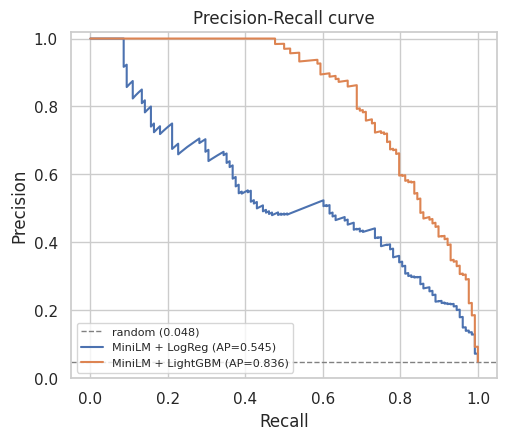

Saved /content/Fake_Job_Postings_Detection/reports/figures/16_minilm_confusion_matrix.png


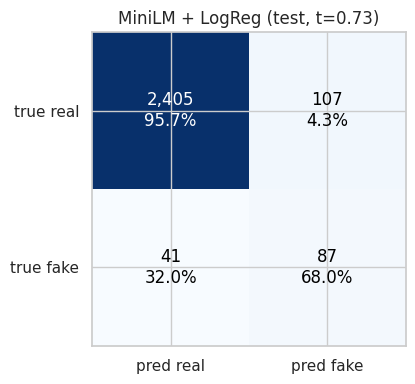

In [12]:
ax = evaluation.plot_pr_curve(y_test, proba_test, label="MiniLM + LogReg")
evaluation.plot_pr_curve(y_test, proba_test_lgbm, label="MiniLM + LightGBM", ax=ax,
                         save_as="15_minilm_pr_curve.png")
plt.show()

evaluation.plot_confusion_matrix(y_test, (proba_test >= best_threshold).astype(int),
                                 title=f"MiniLM + LogReg (test, t={best_threshold:.2f})",
                                 save_as="16_minilm_confusion_matrix.png")
plt.show()

## Compare every model scored so far

Each notebook wrote `models/predictions_<name>_test.csv` on the **same test split**,
so the curves below are directly comparable. Whatever has been run shows up; the
DistilBERT row appears once you drop its predictions file in from Colab.

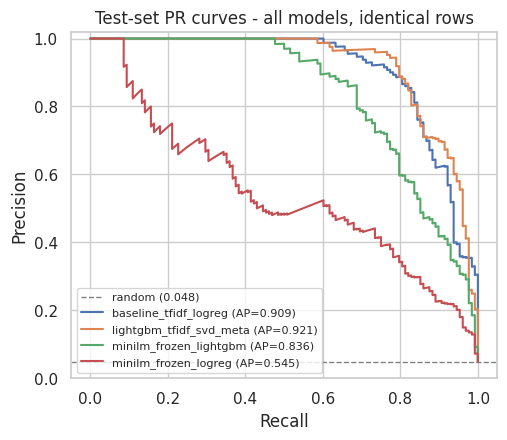

                  model  average_precision  roc_auc
lightgbm_tfidf_svd_meta             0.9211   0.9918
  baseline_tfidf_logreg             0.9095   0.9912
 minilm_frozen_lightgbm             0.8360   0.9798
   minilm_frozen_logreg             0.5454   0.9466


In [13]:
prediction_files = sorted(config.MODELS_DIR.glob("predictions_*_test.csv"))
if not prediction_files:
    print("No prediction files yet - run notebooks 02 and 03 first.")
else:
    ax = None
    summary = []
    for path in prediction_files:
        name = path.stem.replace("predictions_", "").replace("_test", "")
        frame = pd.read_csv(path)
        ax = evaluation.plot_pr_curve(frame["y_true"], frame["y_proba"], label=name, ax=ax)
        metrics = evaluation.evaluate_predictions(frame["y_true"], frame["y_proba"])
        summary.append({"model": name,
                        "average_precision": metrics["average_precision"],
                        "roc_auc": metrics["roc_auc"]})
    ax.set_title("Test-set PR curves - all models, identical rows")
    ax.figure.savefig(config.FIGURES_DIR / "17_model_comparison_pr.png", dpi=150,
                      bbox_inches="tight")
    plt.show()
    print(pd.DataFrame(summary).sort_values("average_precision", ascending=False)
          .round(4).to_string(index=False))

In [16]:
# Full experiment log, test rows ranked by the primary metric (AP).
# load_experiments() shows val only by design; here we surface test for the README.

log = pd.read_csv(config.EXPERIMENTS_CSV)
test_rows = log[log["split"] == "test"].sort_values("average_precision", ascending=False)
cols = ["model", "average_precision", "roc_auc", "f1", "precision", "recall", "threshold"]
print(test_rows[cols].round(4).to_string(index=False))

                  model  average_precision  roc_auc     f1  precision  recall  threshold
lightgbm_tfidf_svd_meta             0.9211   0.9918 0.7904     0.7055  0.8984     0.0948
  baseline_tfidf_logreg             0.9095   0.9912 0.7774     0.7097  0.8594     0.4481
 minilm_frozen_lightgbm             0.8360   0.9798 0.6842     0.5909  0.8125     0.0048
   minilm_frozen_logreg             0.5454   0.9466 0.5404     0.4485  0.6797     0.7342


## Conclusions

**Frozen MiniLM embeddings do not beat TF-IDF here** - best test PR-AUC 0.836
(LightGBM head) vs. the baseline's 0.909 and the tabular LightGBM's 0.921. Dense
semantic vectors, encoded once from a frozen `all-MiniLM-L6-v2`, carry a real signal (ROC-AUC 0.98) but rank the minority class worse than a plain bag-of-words. Two model-specific ceilings explain it: MiniLM truncates input at 256 tokens - our `full_text` (title + profile + description + requirements + benefits) routinely runs longer, so late signal is unseen - and mean-pooling blurs the sharp lexical triggers (`$5000`, `data entry`, `work from home`) that TF-IDF keeps explicit.

**The classifier head matters more than the embedding.** On the *same* 384-dim
vectors, LogReg scores 0.545 and LightGBM 0.836 - a 0.29 AP gap, larger than the gap between any two model families. A linear boundary underfits the embedding space (train AP 0.63 ~ val 0.59: not overfitting, but hitting the ceiling of a flat hyperplane); gradient-boosted trees carve the non-linear structure the same vectors already hold. The lesson is that dense embeddings are not linearly separable for this task, so the head is not an afterthought.

**Practical takeaway.** F2 thresholds span two orders of magnitude across models
(0.005 to 0.734), confirming why 0.5 is never left as default - each model's
probabilities live on their own scale. Frozen embeddings buy a cheap, no-training text model, but on this dataset surface lexical cues win. The open question - whether a model that reads the text *in full and fine-tuned* can beat TF-IDF - is exactly what


Next: `05_distilbert_colab.ipynb` - upload it to Colab with a GPU runtime, along
with `data/processed/*.csv`.